In [1]:
import paramiko
import time
import re
import os
import glob
from pathlib import Path


# Define paths

This notebook starts from multiple session `.raw` files under `main_folder`, concatenates them into `main_folder/output_concat/`, then runs **motion correction on the concatenated raw**.


In [38]:
# Local main folder
#main_folder_local = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake' # 4X4
#main_folder_local = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce45/2026-01-18_pAce45/PX/post/Awake' # 4X4, start from 3C next week
#main_folder_local = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce38/2025-11-26_pAce38/PX/post/Awake' # 4X4
#main_folder_local = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce21/2025-08-06_pAce21_PR/Awake' # 2X2, redo step 3
#main_folder_local = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce28/2025-08-11-pAce28/Awake' # 2X2

#main_folder_local = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce46/2026-02-22_pAce46/PR/post/Awake'
#main_folder_local = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce50/2025-03-17_pAce50_PRL/Awake'
main_folder_local = '/Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce54/2026-05-06_pAce54/PR/post/Awake'

# Cluster path mapping
main_folder = main_folder_local.replace('/Volumes/adam-lab', '/ems/elsc-labs/adam-y')

output_concat_subdir = 'output_concat'
output_concat = os.path.join(main_folder, output_concat_subdir)
output_concat_local = output_concat.replace('/ems/elsc-labs/adam-y', '/Volumes/adam-lab')

# Concatenated dataset settings
concat_raw_name = 'Image_001_001.raw'
frames_to_truncate_per_session = 500  # applied BEFORE concatenation (per-session)

# Motion correction settings (run on concatenated raw)
mc_output_subdir = 'output_final'
mc_run_tag = 'concat_mc'  # set to None to write directly under output_final/
mc_factor = (1, 1)
# if main_folder_local contains 'pAce21', then use mc_factor = (2, 2) instead of (1, 1)
if 'pAce21' in main_folder_local or 'pAce28' in main_folder_local:
    mc_factor = (2, 2)
    print('Using mc_factor (2, 2) for pAce21/pAce28 dataset')
mc_skip_roi_detection = True

print('main_folder_local:', main_folder_local)
print('output_concat_local:', output_concat_local)


main_folder_local: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce54/2026-05-06_pAce54/PR/post/Awake
output_concat_local: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce54/2026-05-06_pAce54/PR/post/Awake/output_concat


In [39]:
# Define cluster login details
CLUSTER_HOST = 'loginserver.elsc.huji.ac.il'
USERNAME = 'qixin.yang'
SSH_KEY_PATH = os.path.expanduser('~/.ssh/id_rsa')  # optional; set to None to use SSH agent

# Pipeline workdir + python runner
PIPELINE_WORKDIR = '/ems/elsc-labs/adam-y/qixin.yang/ClusterCode/miniVI_Renana_Pipeline'
sh_script = '/ems/elsc-labs/adam-y/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/utils/run_python_job.sh'

ssh = paramiko.SSHClient()
ssh.set_missing_host_key_policy(paramiko.AutoAddPolicy())
kwargs = {}
if SSH_KEY_PATH and os.path.exists(SSH_KEY_PATH):
    kwargs['key_filename'] = SSH_KEY_PATH
ssh.connect(CLUSTER_HOST, username=USERNAME, **kwargs)
print('[INFO] Connected to cluster.')


[INFO] Connected to cluster.


In [40]:
def run_command(command):
    """Runs a command on the cluster with a login shell"""
    full_command = f"bash -l -c '{command}'"
    stdin, stdout, stderr = ssh.exec_command(full_command)
    output = stdout.read().decode().strip()
    error = stderr.read().decode().strip()
    return output, error

def wait_for_jobs(job_ids, poll_interval=30):
    """Poll SLURM until all jobs complete. Returns True if all succeeded."""
    import time
    from IPython.display import clear_output

    if not job_ids:
        print('No jobs to wait for.')
        return True

    pending_jobs = set(job_ids)
    failed_jobs = []

    while pending_jobs:
        # Check job status
        job_list = ','.join(pending_jobs)
        command = f"sacct -j {job_list} --format=JobID,State,ExitCode -n -P"
        output, error = run_command(command)

        if error and 'Invalid job id' not in error:
            print(f"[WARNING] Error checking jobs: {error}")

        # Parse output
        completed = set()
        for line in output.strip().splitlines():
            if not line or '.' in line.split('|')[0]:  # Skip sub-jobs like "12345.batch"
                continue
            parts = line.split('|')
            if len(parts) >= 2:
                job_id, state = parts[0], parts[1]
                if state in ['COMPLETED', 'FAILED', 'CANCELLED', 'TIMEOUT']:
                    completed.add(job_id)
                    if state != 'COMPLETED':
                        failed_jobs.append((job_id, state))

        pending_jobs -= completed

        clear_output(wait=True)
        print(f"[{time.strftime('%H:%M:%S')}] Jobs status:")
        print(f"  Completed: {len(job_ids) - len(pending_jobs)}/{len(job_ids)}")
        print(f"  Pending: {len(pending_jobs)}")
        if failed_jobs:
            print(f"  Failed: {failed_jobs}")

        if pending_jobs:
            print()
            print(f"Waiting {poll_interval}s before next check...")
            time.sleep(poll_interval)

    print()
    print('=' * 50)
    if failed_jobs:
        print(f"WARNING: {len(failed_jobs)} jobs failed: {failed_jobs}")
        return False

    print('All jobs completed successfully!')
    return True



# Step 0: Discover sessions and `.raw` files

Discovers `*-good` folders directly under `main_folder_local` and picks one `.raw` per session (prefers `Image_001_001.raw`).


In [41]:
session_folders_local = sorted([
    p for p in glob.glob(os.path.join(main_folder_local, '*'))
    if os.path.isdir(p) and re.search(r'(^|/)\d+-good$', p)
])
print(f'Found {len(session_folders_local)} session folders.')
for p in session_folders_local:
    print('  -', p)

raw_paths_local = []
for sess in session_folders_local:
    raws = sorted(glob.glob(os.path.join(sess, '**', '*.raw'), recursive=True))
    if not raws:
        print('[WARN] No .raw found under:', sess)
        continue

    preferred = [p for p in raws if os.path.basename(p) == 'Image_001_001.raw']
    pick = preferred[0] if preferred else raws[0]
    if len(raws) > 1:
        print('[WARN] Multiple .raw found under:', sess)
        for p in raws:
            print('    -', p)
        print('    -> using:', pick)
    raw_paths_local.append(pick)

raw_paths_local = sorted(raw_paths_local)
raw_paths = [p.replace('/Volumes/adam-lab', '/ems/elsc-labs/adam-y') for p in raw_paths_local]

print()
print('Final list of .raw file paths (cluster):')
for p in raw_paths:
    print(p)


Found 1 session folders.
  - /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce54/2026-05-06_pAce54/PR/post/Awake/2-good
[WARN] Multiple .raw found under: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce54/2026-05-06_pAce54/PR/post/Awake/2-good
    - /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce54/2026-05-06_pAce54/PR/post/Awake/2-good/60mwmmmmm-20min_001/Image_001_001.raw
    - /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce54/2026-05-06_pAce54/PR/post/Awake/2-good/60mwmmmmm-20min_001/ROIMask.raw
    -> using: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce54/2026-05-06_pAce54/PR/post/Awake/2-good/60mwmmmmm-20min_001/Image_001_001.raw

Final list of .raw file paths (cluster):
/ems/elsc-labs/adam-y/Adam-Lab-Shared/Data/renana_malka/pAce54/2026-05-06_pAce54/PR/post/Awake/2-good/60mwmmmmm-20min_001/Image_001_001.raw


# Step 1: Concatenate the raw sessions

Builds `output_concat/Image_001_001.raw` on the cluster and copies `Experiment.xml` + `ROIs.xaml` into `output_concat/` so motion correction can run on the concatenated dataset.


In [7]:
python_script = 'utils/DS_motion_correction_concat.py'
LOG_DIR = f"{PIPELINE_WORKDIR}/logs"
LOG_DIR_LOCAL = LOG_DIR.replace('/ems/elsc-labs/adam-y', '/Volumes/adam-lab')
JOB_NAME = 'DS_motion_correction_concat'

# Ensure output + logs directories exist on the cluster
_, mkdir_err = run_command(f"mkdir -p {LOG_DIR} {output_concat}")
if mkdir_err:
    print(f"[WARN] mkdir returned: {mkdir_err}")

raw_args = ' '.join([f"--raw {p}" for p in raw_paths])
cmd = (
    f"sbatch --job-name {JOB_NAME} --chdir {PIPELINE_WORKDIR} "
    f"--output {LOG_DIR}/%x_%j.out --error {LOG_DIR}/%x_%j.err "
    f"{sh_script} {PIPELINE_WORKDIR} {python_script} "
    f"--out-dir {output_concat} "
    f"--out-raw-name {concat_raw_name} "
    f"--frames-to-truncate-per-session {frames_to_truncate_per_session} "
    f"--overwrite "
    f"--mc-output-subdir {mc_output_subdir} "
    + (f"--mc-run-tag {mc_run_tag} " if mc_run_tag else "--mc-run-tag '' ")
    + f"--factor {mc_factor[0]} {mc_factor[1]} "
    + ("--skip-roi-detection " if mc_skip_roi_detection else "")
    + raw_args
)

output, error = run_command(cmd)
concat_mc_job_id = None
if error:
    print(f"[ERROR] Failed to submit concat+MC job: {error}")
else:
    print(f"[INFO] Concat+MC job submitted: {output}")
    match = re.search(r'Submitted batch job (\d+)', output)
    if match:
        concat_mc_job_id = match.group(1)
        print(f"[INFO] Job ID: {concat_mc_job_id}")
        print(f"[INFO] Slurm .out (local): {LOG_DIR_LOCAL}/{JOB_NAME}_{concat_mc_job_id}.out")
        print(f"[INFO] Output concat folder (local): {output_concat_local}")


[INFO] Concat+MC job submitted: Submitted batch job 43078393
[INFO] Job ID: 43078393
[INFO] Slurm .out (local): /Volumes/adam-lab/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/logs/DS_motion_correction_concat_43078393.out
[INFO] Output concat folder (local): /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce54/2026-05-06_pAce54/PR/post/Awake/output_concat


# Step 2: Check ROIs and Manually draw ROIs


In [8]:
# Downstream step variables (match Batch_pipeline.ipynb conventions)
concat_raw_path = os.path.join(output_concat, concat_raw_name)
data_file_paths = [concat_raw_path]
OUTPUT_SUBDIR = mc_output_subdir
RUN_TAG = mc_run_tag
print('data_file_paths:', data_file_paths)
print('OUTPUT_SUBDIR:', OUTPUT_SUBDIR)
print('RUN_TAG:', RUN_TAG)


data_file_paths: ['/ems/elsc-labs/adam-y/Adam-Lab-Shared/Data/renana_malka/pAce54/2026-05-06_pAce54/PR/post/Awake/output_concat/Image_001_001.raw']
OUTPUT_SUBDIR: output_final
RUN_TAG: concat_mc


In [22]:
# Check ROIs (motion corrected only)
# NOTE: this cell expects `data_file_paths` (created in the `concat_vars` cell).
if 'data_file_paths' not in globals():
    raise NameError('data_file_paths is not defined. Run the `concat_vars` cell first.')

import os
import numpy as np
from tifffile import imread
import matplotlib.pyplot as plt

vmax = 0.95

OUTPUT_SUBDIR = globals().get('OUTPUT_SUBDIR', 'output_final')
RUN_TAG = globals().get('RUN_TAG', None)

def output_dir_for(raw_path_remote, output_subdir=OUTPUT_SUBDIR, run_tag=RUN_TAG):
    base = os.path.join(os.path.dirname(raw_path_remote), output_subdir)
    return os.path.join(base, run_tag) if run_tag else base

ROI_FILENAME = 'Image_001_001_ROIs.tif'
if mc_factor == (2, 2):
    ROI_FILENAME = 'Image_001_001_ROIs_ds2x2.tif'

data_output_paths = []
for data_file in data_file_paths:
    out_dir = output_dir_for(data_file)

    # replace 'ems/elsc-labs/adam-y' with '/Volumes/adam-lab' to access local file system
    out_dir_local = out_dir.replace('/ems/elsc-labs/adam-y', '/Volumes/adam-lab')
    data_output_paths.append(out_dir_local)

    roi_file = os.path.join(out_dir_local, ROI_FILENAME)
    mean_mc_path = os.path.join(out_dir_local, 'mean_image_mc.tif')
    if not os.path.exists(roi_file):
        print('[WARN] Missing ROI file:', roi_file)
        continue
    if not os.path.exists(mean_mc_path):
        print('[WARN] Missing mean_image_mc.tif:', mean_mc_path)
        continue

    roi_img = imread(roi_file)
    roi_stack = roi_img if roi_img.ndim == 3 else roi_img[None, ...]
    roi_overlay = roi_stack.sum(axis=0)

    mean_img_mc = imread(mean_mc_path)

    fig, ax = plt.subplots(1, 1, figsize=(3,3), constrained_layout=True)
    ax.imshow(mean_img_mc, cmap='gray', vmin=0, vmax=float(mean_img_mc.max()) * vmax)
    ax.imshow(roi_overlay, cmap='jet', alpha=0.2)
    ax.set_title('Mean Image Motion Corrected + ROIs')
    ax.axis('off')

    for i in range(roi_stack.shape[0]):
        ys, xs = np.nonzero(roi_stack[i])
        if len(xs) and len(ys):
            ax.text(float(xs.mean()), float(ys.mean()), str(i + 1), color='white', fontsize=10, ha='center', va='center')

    plt.show()


[WARN] Missing ROI file: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce54/2026-05-06_pAce54/PR/post/Awake/output_concat/output_final/concat_mc/Image_001_001_ROIs.tif


In [10]:
# Call ROI GUI for batch ROI drawing

def run_ROI_app(output_paths):
    import subprocess
    args = ['python', '../utils/DrawROI_GUI_batch.py'] + output_paths
    print('Running command:', ' '.join(args))
    subprocess.run(args)

run_ROI_app(data_output_paths)


Running command: python ../utils/DrawROI_GUI_batch.py /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce54/2026-05-06_pAce54/PR/post/Awake/output_concat/output_final/concat_mc


/Users/qixinyang/Documents/AdamLab/miniVI_Renana_Pipeline/notebooks/../utils/DrawROI_GUI_batch.py:105: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl_cm.get_cmap("jet")


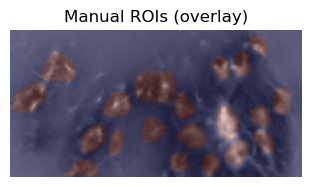

In [11]:
# Display manually drawn ROIs (if they exist)
import os
import numpy as np
import matplotlib.pyplot as plt
from tifffile import imread

V_MAX_FACTOR = 0.95

def _load_manual_rois(folder):
    npz_path = os.path.join(folder, 'manual_ROIs.npz')
    if not os.path.exists(npz_path):
        return None
    with np.load(npz_path, allow_pickle=True) as d:
        if 'ROIs' not in d:
            raise KeyError("Expected key 'ROIs' in {}".format(npz_path))
        rois = np.asarray(d['ROIs']).astype(bool)
    if rois.ndim == 2:
        rois = rois[None, ...]
    return rois

if 'data_output_paths' not in globals():
    print('[WARN] data_output_paths is not defined (run the Step 2 setup cells first).')
else:
    for folder in data_output_paths:
        rois = _load_manual_rois(folder)
        if rois is None:
            print('[INFO] No manual_ROIs.npz in:', folder)
            continue

        mean_mc_path = os.path.join(folder, 'mean_image_mc.tif')
        if not os.path.exists(mean_mc_path):
            print('[WARN] Missing mean_image_mc.tif in:', folder)
            continue

        mean_mc = imread(mean_mc_path)
        overlay = rois.astype(np.uint8).sum(axis=0)

        fig, ax = plt.subplots(1, 1, figsize=(3,3), constrained_layout=True)
        ax.imshow(mean_mc, cmap='gray', vmin=0, vmax=float(mean_mc.max()) * V_MAX_FACTOR)
        ax.imshow(overlay, cmap='jet', alpha=0.25)
        ax.set_title('Manual ROIs (overlay)')
        ax.axis('off')
        plt.show()


# Step 2.5: Masked motion-regression denoising (ROI-only)

Run after Step 2. Writes `movReg_denoised_masked.tif` into the concatenated output folder.


In [12]:
# Downstream step variables (match Batch_pipeline.ipynb conventions)
concat_raw_path = os.path.join(output_concat, concat_raw_name)
data_file_paths = [concat_raw_path]
OUTPUT_SUBDIR = mc_output_subdir
RUN_TAG = mc_run_tag
print('data_file_paths:', data_file_paths)
print('OUTPUT_SUBDIR:', OUTPUT_SUBDIR)
print('RUN_TAG:', RUN_TAG)


data_file_paths: ['/ems/elsc-labs/adam-y/Adam-Lab-Shared/Data/renana_malka/pAce54/2026-05-06_pAce54/PR/post/Awake/output_concat/Image_001_001.raw']
OUTPUT_SUBDIR: output_final
RUN_TAG: concat_mc


In [13]:
# Submit masked motion-regression job (concatenated output)
python_script = 'utils/motion_regression_masked.py'
LOG_DIR = f"{PIPELINE_WORKDIR}/logs"
LOG_DIR_LOCAL = LOG_DIR.replace('/ems/elsc-labs/adam-y', '/Volumes/adam-lab')
JOB_NAME = 'masked_motion_reg_concat'
MASKED_OUT_NAME = 'movReg_denoised_masked.tif'
CHUNK_FRAMES = 30000 # 60s 
OVERLAP_FRAMES = 2000  # crossfade overlap to reduce chunk-edge discontinuities
PIXEL_BLOCK = 5000
DILATE_PX = 8
KEEP_OUTSIDE_MASK = False

_, mkdir_err = run_command(f"mkdir -p {LOG_DIR}")
if mkdir_err:
    print(f"[WARN] Failed to create log dir on cluster: {mkdir_err}")

data_file = data_file_paths[0]
out_dir = os.path.join(os.path.dirname(data_file), OUTPUT_SUBDIR)
if RUN_TAG:
    out_dir = os.path.join(out_dir, RUN_TAG)

cmd = (
    f"sbatch --job-name {JOB_NAME} --mem=64G --chdir {PIPELINE_WORKDIR} "
    f"--output {LOG_DIR}/%x_%j.out --error {LOG_DIR}/%x_%j.err "
    f"{sh_script} {PIPELINE_WORKDIR} {python_script} {out_dir} "
    f"--out-name {MASKED_OUT_NAME} --chunk-frames {CHUNK_FRAMES} --overlap-frames {OVERLAP_FRAMES} "
    f"--pixel-block {PIXEL_BLOCK} --dilate-px {DILATE_PX}"
)
if KEEP_OUTSIDE_MASK:
    cmd += ' --keep-outside-mask'

output, error = run_command(cmd)
masked_job_id = None
if error:
    print(f"[ERROR] Failed to submit masked motion-regression for {out_dir}: {error}")
else:
    print(f"[INFO] Masked motion-regression job submitted for {out_dir}: {output}")
    match = re.search(r'Submitted batch job (\d+)', output)
    if match:
        masked_job_id = match.group(1)
        print(f"[INFO] Job ID: {masked_job_id}")
        print(f"[INFO] Slurm .out (local): {LOG_DIR_LOCAL}/{JOB_NAME}_{masked_job_id}.out")


[INFO] Masked motion-regression job submitted for /ems/elsc-labs/adam-y/Adam-Lab-Shared/Data/renana_malka/pAce54/2026-05-06_pAce54/PR/post/Awake/output_concat/output_final/concat_mc: Submitted batch job 43078421
[INFO] Job ID: 43078421
[INFO] Slurm .out (local): /Volumes/adam-lab/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/logs/masked_motion_reg_concat_43078421.out


In [ ]:
# Make a side-by-side preview: movReg | movReg_denoised_masked (run after Step 2.5 completes)
python_script = 'utils/DS_make_previews.py'
LOG_DIR = f"{PIPELINE_WORKDIR}/logs"
LOG_DIR_LOCAL = LOG_DIR.replace('/ems/elsc-labs/adam-y', '/Volumes/adam-lab')
JOB_NAME = 'DS_make_previews_masked_concat'

PREVIEW_SECONDS = 120.0
PREVIEW_FPS = 50.0
PREVIEW_START = 1000
FORCE_PREVIEWS = False

_, mkdir_err = run_command(f"mkdir -p {LOG_DIR}")
if mkdir_err:
    print(f"[WARN] Failed to create log dir on cluster: {mkdir_err}")

data_file = data_file_paths[0]
out_dir = os.path.join(os.path.dirname(data_file), OUTPUT_SUBDIR)
if RUN_TAG:
    out_dir = os.path.join(out_dir, RUN_TAG)

dep = f"--dependency=afterok:{masked_job_id} " if masked_job_id else ''
cmd = (
    f"sbatch {dep}--job-name {JOB_NAME} --chdir {PIPELINE_WORKDIR} "
    f"--output {LOG_DIR}/%x_%j.out --error {LOG_DIR}/%x_%j.err "
    f"{sh_script} {PIPELINE_WORKDIR} {python_script} {out_dir} "
    f"--preview-seconds {PREVIEW_SECONDS} --preview-fps {PREVIEW_FPS} "
    f"--preview-start {int(PREVIEW_START)} --only-movreg --movreg-denoised-masked"
)
if FORCE_PREVIEWS:
    cmd += ' --force'

output, error = run_command(cmd)
if error:
    print(f"[ERROR] Failed to submit preview job for {out_dir}: {error}")
else:
    print(f"[INFO] Preview job submitted for {out_dir}: {output}")
    match = re.search(r'Submitted batch job (\d+)', output)
    if match:
        job_id = match.group(1)
        print(f"[INFO] Job ID: {job_id}")
        print(f"[INFO] Slurm .out (local): {LOG_DIR_LOCAL}/{JOB_NAME}_{job_id}.out")


[INFO] Preview job submitted for /ems/elsc-labs/adam-y/Adam-Lab-Shared/Data/renana_malka/pAce47/2026-01-28_pAce47/PX/post/Awake/output_concat/output_final/concat_mc: Submitted batch job 15120588
[INFO] Job ID: 15120588
[INFO] Slurm .out (local): /Volumes/adam-lab/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/logs/DS_make_previews_masked_concat_15120588.out


# Step 3: Demix (Chunked - Memory Efficient)


In [33]:
concat_raw_path = os.path.join(output_concat, concat_raw_name)
data_file_paths = [concat_raw_path]
OUTPUT_SUBDIR = mc_output_subdir
RUN_TAG = mc_run_tag

In [34]:
new_data_extension = 'movReg_denoised_masked.tif'

mc_denoised_file_paths = []
for data_file in data_file_paths:
    out_dir = os.path.join(os.path.dirname(data_file), OUTPUT_SUBDIR)
    if RUN_TAG:
        out_dir = os.path.join(out_dir, RUN_TAG)
    denoised_file = os.path.join(out_dir, new_data_extension)
    denoised_file_local = denoised_file.replace('/ems/elsc-labs/adam-y', '/Volumes/adam-lab')
    if os.path.exists(denoised_file_local):
        print(f"Denoised file exists: {denoised_file_local}")
        mc_denoised_file_paths.append(denoised_file)
    else:
        print(f"Denoised file NOT found: {denoised_file_local}")

Denoised file exists: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce54/2026-05-06_pAce54/PR/post/Awake/output_concat/output_final/concat_mc/movReg_denoised_masked.tif


## Step 3: Cluster-Side Orchestrator (Single Submit)

Run cell 22 once to submit one SLURM orchestrator job.
Inside that job, Step 3b demix chunks are submitted as separate SLURM jobs simultaneously.
Run cell 23 only if you want to monitor completion from the notebook.


In [ ]:
# Step 3 submit (non-blocking): run cluster-side orchestrator
LOG_DIR = f"{PIPELINE_WORKDIR}/logs"
LOG_DIR_LOCAL = LOG_DIR.replace('/ems/elsc-labs/adam-y', '/Volumes/adam-lab')
JOB_NAME = 'step3_orchestrator_concat'

DILATION = 10
DEMIX_MEM_GB = 64
DEMIX_LAUNCH_MODE = 'sbatch'   # 'sbatch' => submit all chunk demix jobs simultaneously
DEMIX_POLL_SECONDS = 10
MAX_CHUNKS_PARALLEL = 1        # only used if DEMIX_LAUNCH_MODE='local'
STRICT_MODE = False

python_script = 'utils/run_step3_chunk_demix_concat.py'

# Ensure logs dir exists
_, mkdir_err = run_command(f"mkdir -p {LOG_DIR}")
if mkdir_err:
    print(f"[WARN] Failed to create log dir on cluster: {mkdir_err}")

# Build repeated --data-file args
data_args = ' '.join([f"--data-file {p}" for p in mc_denoised_file_paths])
if not data_args:
    raise RuntimeError('mc_denoised_file_paths is empty. Nothing to submit for Step 3.')

strict_flag = '--strict' if STRICT_MODE else '--no-strict'
cmd = (
    f"sbatch --job-name {JOB_NAME} --chdir {PIPELINE_WORKDIR} "
    f"--output {LOG_DIR}/%x_%j.out --error {LOG_DIR}/%x_%j.err "
    f"{sh_script} {PIPELINE_WORKDIR} {python_script} "
    f"--pipeline-workdir {PIPELINE_WORKDIR} "
    f"--dilation {int(DILATION)} "
    f"--demix-mem-gb {int(DEMIX_MEM_GB)} "
    f"--demix-launch-mode {DEMIX_LAUNCH_MODE} "
    f"--demix-poll-seconds {int(DEMIX_POLL_SECONDS)} "
    f"--max-chunks-parallel {int(MAX_CHUNKS_PARALLEL)} "
    f"{strict_flag} "
    f"--log-prefix STEP3 "
    + data_args
)

output, error = run_command(cmd)
step3_job_id = None
if error:
    print(f"[ERROR] Failed to submit Step 3 orchestrator job: {error}")
else:
    print(f"[INFO] Step 3 orchestrator submitted: {output}")
    m = re.search(r'Submitted batch job (\d+)', output)
    if m:
        step3_job_id = m.group(1)
        print(f"[INFO] Step 3 Job ID: {step3_job_id}")
        print(f"[INFO] Slurm .out (local): {LOG_DIR_LOCAL}/{JOB_NAME}_{step3_job_id}.out")
        print(f"[INFO] Slurm .err (local): {LOG_DIR_LOCAL}/{JOB_NAME}_{step3_job_id}.err")
        print('[INFO] Submission is non-blocking. Run the next cell to monitor optionally.')


[INFO] Step 3 orchestrator submitted: Submitted batch job 43078453
[INFO] Step 3 Job ID: 43078453
[INFO] Slurm .out (local): /Volumes/adam-lab/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/logs/step3_orchestrator_concat_43078453.out
[INFO] Slurm .err (local): /Volumes/adam-lab/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/logs/step3_orchestrator_concat_43078453.err
[INFO] Submission is non-blocking. Run the next cell to monitor optionally.


Socket exception: Connection reset by peer (54)
Socket exception: Connection reset by peer (54)


In [36]:
# Optional: monitor the single Step 3 orchestrator job
if 'step3_job_id' in globals() and step3_job_id:
    wait_for_jobs([step3_job_id], poll_interval=10)
else:
    print('[INFO] No step3_job_id found. Submit Step 3 first.')


SSHException: SSH session not active

# Step 4: Spike Detection


In [42]:
# Locate the demixed results pickle (local path)
concat_raw_path = os.path.join(output_concat, concat_raw_name)
new_data_extension = 'volpy_demix_results.pickle'
data_file_paths = [concat_raw_path]
OUTPUT_SUBDIR = mc_output_subdir
RUN_TAG = mc_run_tag

mc_denoised_file_paths = []
for data_file in data_file_paths:
    out_dir = os.path.join(os.path.dirname(data_file), OUTPUT_SUBDIR)
    if RUN_TAG:
        out_dir = os.path.join(out_dir, RUN_TAG)
    denoised_file = os.path.join(out_dir, new_data_extension)
    denoised_file_local = denoised_file.replace('/ems/elsc-labs/adam-y', '/Volumes/adam-lab')
    if os.path.exists(denoised_file_local):
        mc_denoised_file_paths.append(denoised_file)
    else:
        print(f"[WARN] Denoised file NOT found: {denoised_file_local}")
demix_file = None
for data_file in mc_denoised_file_paths:
    cand = os.path.join(os.path.dirname(data_file), 'volpy_demix_results.pickle')
    cand_local = cand.replace('/ems/elsc-labs/adam-y', '/Volumes/adam-lab')
    if os.path.exists(cand_local):
        demix_file = cand_local
        print('[INFO] Found:', demix_file)
    else:
        print('[WARN] Missing:', cand_local)


[INFO] Found: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce54/2026-05-06_pAce54/PR/post/Awake/output_concat/output_final/concat_mc/volpy_demix_results.pickle


In [ ]:
# Launch Dash overview app with the demix pickle derived from concat_raw_path
import subprocess, os

out_dir = os.path.join(os.path.dirname(concat_raw_path), OUTPUT_SUBDIR)
if RUN_TAG:
    out_dir = os.path.join(out_dir, RUN_TAG)

pickle_path = os.path.join(out_dir, 'volpy_demix_results.pickle')
pickle_path_local = pickle_path.replace('/ems/elsc-labs/adam-y', '/Volumes/adam-lab')

prefer_annotated = True

if prefer_annotated:
    # prefer annotated pickle if it exists
    annotated = pickle_path_local.replace('.pickle', '_annotated.pickle')
    if os.path.exists(annotated):
        pickle_path_local = annotated
        print(f'[INFO] Using annotated pickle: {pickle_path_local}')
    elif os.path.exists(pickle_path_local):
        print(f'[INFO] Using pickle: {pickle_path_local}')
    else:
        raise FileNotFoundError(f'Pickle not found: {pickle_path_local}')

app_script = '/Volumes/adam-lab/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/dash_overview_app/app.py'
args = ['python', app_script, pickle_path_local]
print('Running command:', ' '.join(args))
subprocess.run(args)

[INFO] Using pickle: /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce50/2025-03-17_pAce50_PRL/Awake/output_concat/output_final/concat_mc/volpy_demix_results.pickle
Running command: python /Volumes/adam-lab/qixin.yang/ClusterCode/miniVI_Renana_Pipeline/dash_overview_app/app.py /Volumes/adam-lab/Adam-Lab-Shared/Data/renana_malka/pAce50/2025-03-17_pAce50_PRL/Awake/output_concat/output_final/concat_mc/volpy_demix_results.pickle
Dash is running on http://127.0.0.1:8050/

 * Serving Flask app 'app'
 * Debug mode: off


 * Running on http://127.0.0.1:8050
Press CTRL+C to quit
127.0.0.1 - - [18/Mar/2026 13:21:29] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [18/Mar/2026 13:21:29] "GET /_dash-component-suites/dash/deps/react@18.v4_0_0m1770397671.3.1.min.js HTTP/1.1" 200 -
127.0.0.1 - - [18/Mar/2026 13:21:29] "GET /_dash-component-suites/dash/deps/polyfill@7.v4_0_0m1770397671.12.1.min.js HTTP/1.1" 200 -
127.0.0.1 - - [18/Mar/2026 13:21:29] "GET / HTTP/1.1" 200 -
127.0.0.1 - - [18/Mar/2026 13:21:29] "GET /_dash-component-suites/dash/deps/react-dom@18.v4_0_0m1770397671.3.1.min.js HTTP/1.1" 200 -
127.0.0.1 - - [18/Mar/2026 13:21:29] "GET /_dash-component-suites/dash/dash-renderer/build/dash_renderer.v4_0_0m1770397671.min.js HTTP/1.1" 200 -
127.0.0.1 - - [18/Mar/2026 13:21:29] "GET /_dash-component-suites/dash/dcc/dash_core_components.v4_0_0m1770397671.js HTTP/1.1" 200 -
127.0.0.1 - - [18/Mar/2026 13:21:29] "GET /_dash-component-suites/dash/dcc/dash_core_components-shared.v4_0_0m1770397671.js HTTP/1.1" 200 -
127.0.0

KeyboardInterrupt: 

# Run DeepLabCut for behavior analysis